# Dimensionality Reduction using PCA and t-SNE

**Hackoweek Task:** Implement PCA (Principal Component Analysis) and t-SNE for dimensionality reduction and visualization.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

from google.colab import files
from IPython.display import display

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
uploaded = files.upload()

if not uploaded:
    raise ValueError("No file uploaded.")

filename = next(iter(uploaded))
df = pd.read_csv(filename)

print(f"Loaded: {filename}")
print("Shape:", df.shape)
display(df.head())

Saving iris_dimensionality_reduction_dataset.csv to iris_dimensionality_reduction_dataset.csv
Loaded: iris_dimensionality_reduction_dataset.csv
Shape: (150, 5)


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [3]:
print("Dataset shape:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nFirst 5 rows:")
display(df.head())

print("\nLast 5 rows:")
display(df.tail())

Dataset shape: (150, 5)

Column names:
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)', 'species']

Data types:
sepal length (cm)    float64
sepal width (cm)     float64
petal length (cm)    float64
petal width (cm)     float64
species               object
dtype: object

First 5 rows:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa



Last 5 rows:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica
149,5.9,3.0,5.1,1.8,virginica


In [4]:
display(df.describe(include="all").T)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
sepal length (cm),150.0,NaN,NaN,NaN,5.843333,0.828066,4.3,5.1,5.8,6.4,7.9
sepal width (cm),150.0,NaN,NaN,NaN,3.057333,0.435866,2.0,2.8,3.0,3.3,4.4
petal length (cm),150.0,NaN,NaN,NaN,3.758,1.765298,1.0,1.6,4.35,5.1,6.9
petal width (cm),150.0,NaN,NaN,NaN,1.199333,0.762238,0.1,0.3,1.3,1.8,2.5
species,150,3,setosa,50,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
missing = df.isnull().sum()

print("Missing values by column:")
display(missing.to_frame("missing_values"))

if missing.sum() == 0:
    print("No missing values found.")
else:
    print("Missing values detected.")

Missing values by column:


,missing_values
sepal length (cm),0
sepal width (cm),0
petal length (cm),0
petal width (cm),0
species,0


No missing values found.


In [6]:
numeric_columns = df.select_dtypes(include=np.number).columns.tolist()

feature_columns = [
    col for col in numeric_columns
    if col.lower() not in {"id", "customerid", "index"}
]

target_column = None
for candidate in ["species", "target", "label", "class"]:
    if candidate in df.columns:
        target_column = candidate
        break

if len(feature_columns) < 2:
    raise ValueError("At least two numerical feature columns are required.")

X = df[feature_columns].copy()

X = X.fillna(X.median())

y = df[target_column].copy() if target_column else None

print("Feature columns:", feature_columns)
print("Target column:", target_column)
print("Feature matrix shape:", X.shape)

if y is not None:
    print("\nClass counts:")
    display(y.value_counts().to_frame("count"))

Feature columns: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Target column: species
Feature matrix shape: (150, 4)

Class counts:


,count
species,
setosa,50
versicolor,50
virginica,50


## Original Data Visualizations

Before reducing dimensionality, we inspect the original feature distributions and relationships.

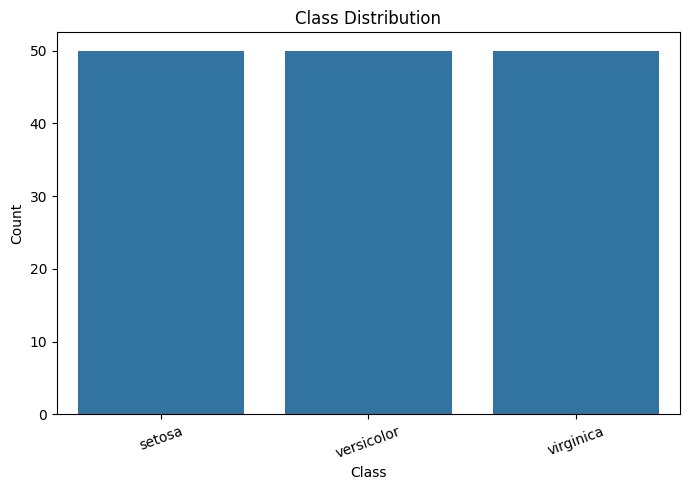

In [7]:
if y is not None:
    plt.figure(figsize=(7, 5))
    sns.countplot(x=y)
    plt.title("Class Distribution")
    plt.xlabel("Class")
    plt.ylabel("Count")
    plt.xticks(rotation=20)
    plt.tight_layout()
    plt.show()
else:
    print("No class/target column detected; skipping class distribution.")

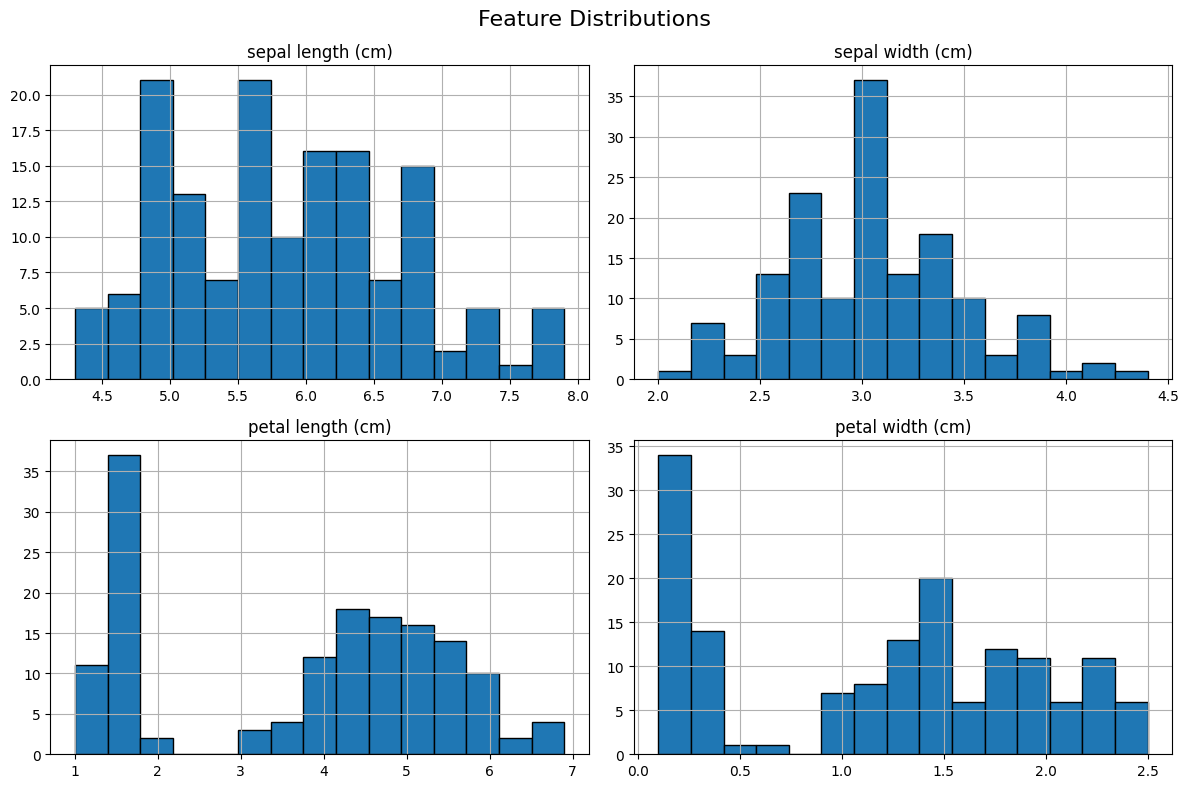

In [8]:
X.hist(figsize=(12, 8), bins=15, edgecolor="black")
plt.suptitle("Feature Distributions", fontsize=16)
plt.tight_layout()
plt.show()

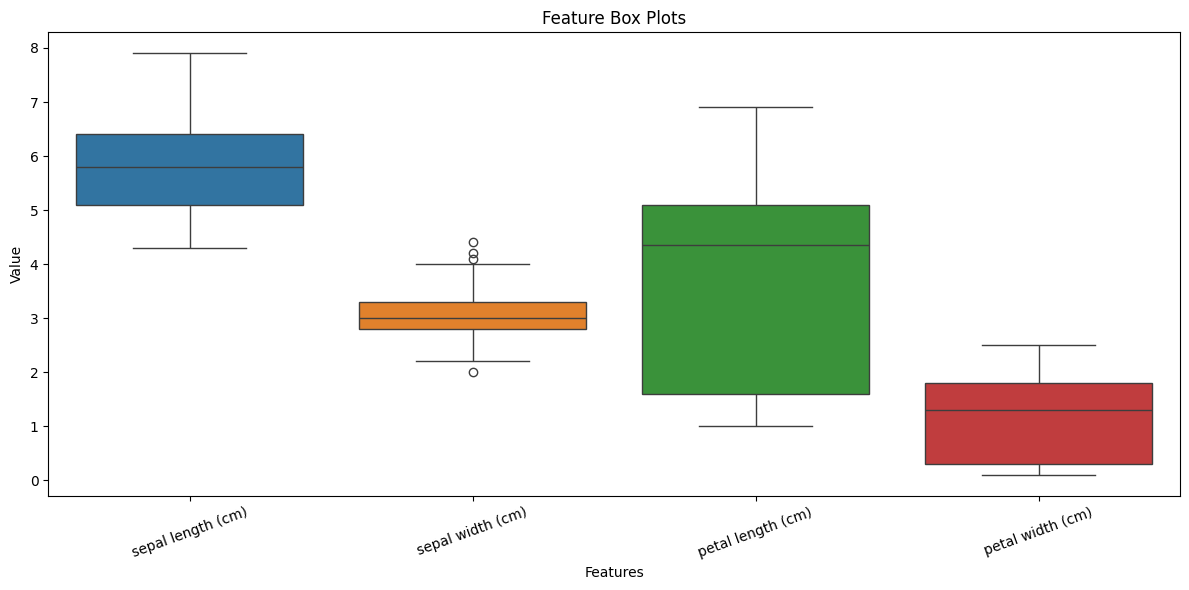

In [9]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=X)
plt.title("Feature Box Plots")
plt.xlabel("Features")
plt.ylabel("Value")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

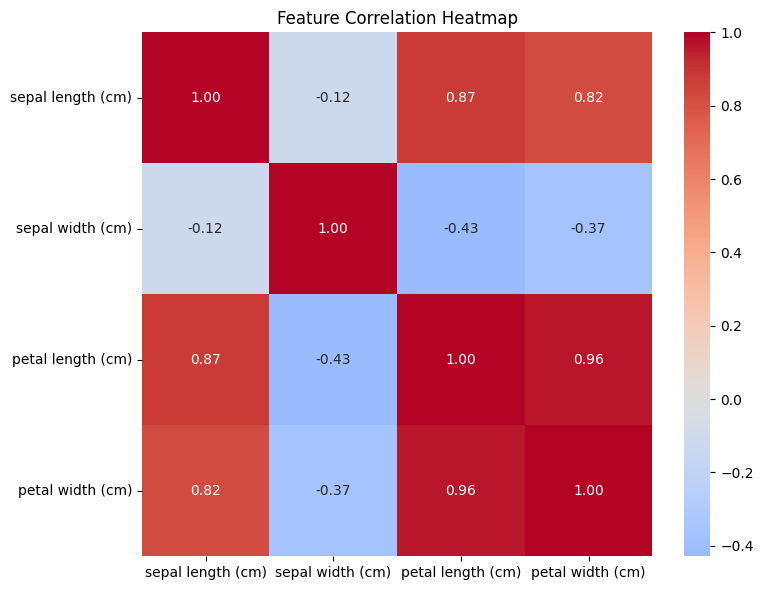

In [10]:
plt.figure(figsize=(8, 6))
sns.heatmap(
    X.corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

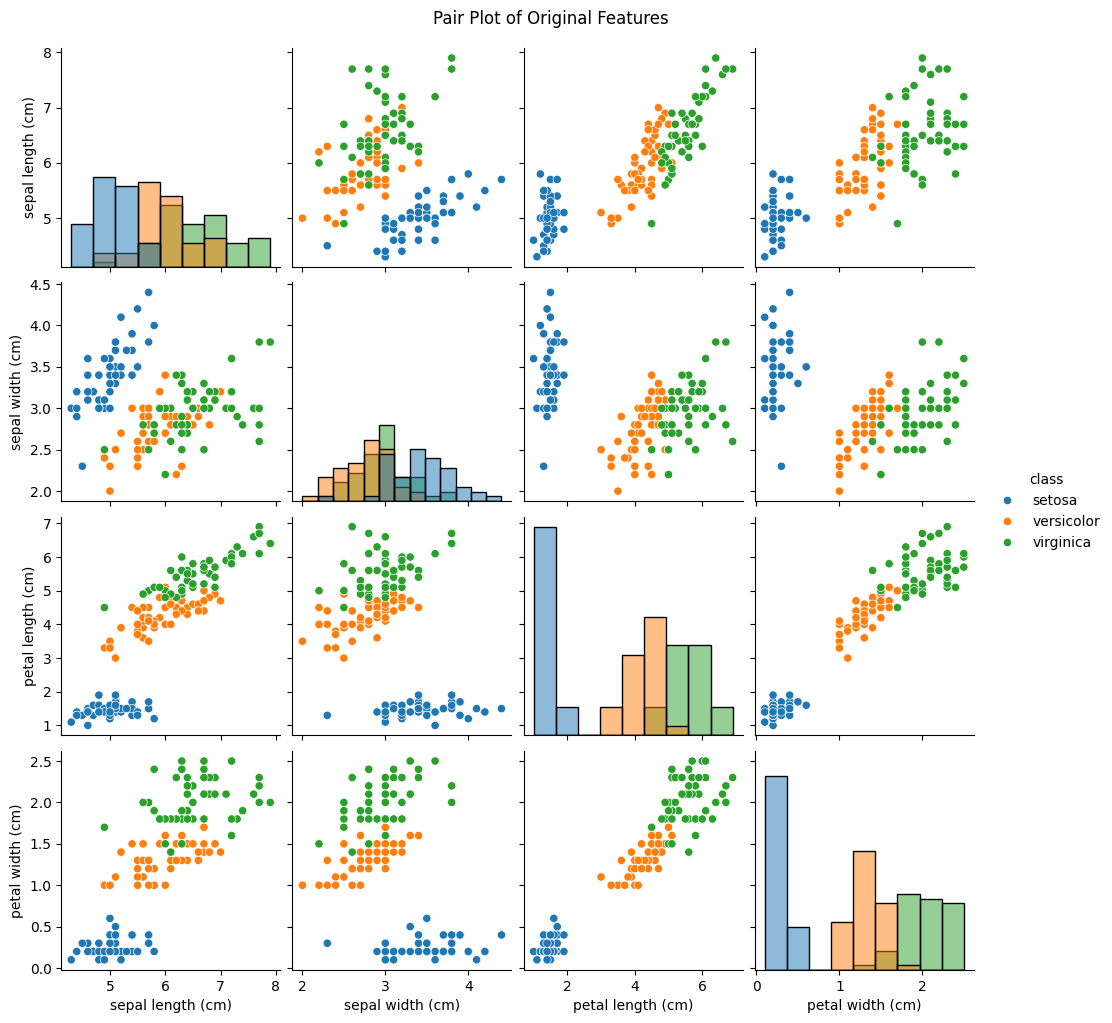

In [11]:
if y is not None:
    pair_df = X.copy()
    pair_df["class"] = y.astype(str)
    sns.pairplot(pair_df, hue="class", diag_kind="hist")
    plt.suptitle("Pair Plot of Original Features", y=1.02)
    plt.show()
else:
    sns.pairplot(X, diag_kind="hist")
    plt.suptitle("Pair Plot of Original Features", y=1.02)
    plt.show()

## Standardization

PCA is variance-based, so features should generally be put on a comparable scale before applying PCA. We also use the standardized data for t-SNE.

In [12]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Standardization complete.")
print("Approximate feature means:", np.round(X_scaled.mean(axis=0), 4))
print("Approximate feature standard deviations:", np.round(X_scaled.std(axis=0), 4))

Standardization complete.
Approximate feature means: [-0. -0. -0. -0.]
Approximate feature standard deviations: [1. 1. 1. 1.]


# PCA — Principal Component Analysis

PCA finds orthogonal directions called principal components that capture decreasing amounts of variance in the data.

In [13]:
pca_full = PCA()
X_pca_full = pca_full.fit_transform(X_scaled)

explained = pca_full.explained_variance_ratio_
cumulative = np.cumsum(explained)

print("Explained variance ratio:")
for i, value in enumerate(explained, start=1):
    print(f"PC{i}: {value:.4f} ({value*100:.2f}%)")

print(f"\nTotal variance explained by all components: {explained.sum()*100:.2f}%")

Explained variance ratio:
PC1: 0.7296 (72.96%)
PC2: 0.2285 (22.85%)
PC3: 0.0367 (3.67%)
PC4: 0.0052 (0.52%)

Total variance explained by all components: 100.00%


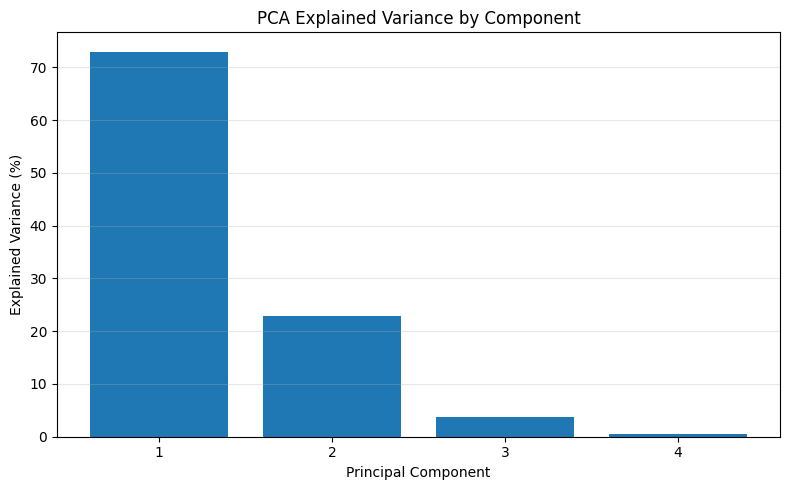

In [14]:
components = np.arange(1, len(explained) + 1)

plt.figure(figsize=(8, 5))
plt.bar(components, explained * 100)
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance (%)")
plt.title("PCA Explained Variance by Component")
plt.xticks(components)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

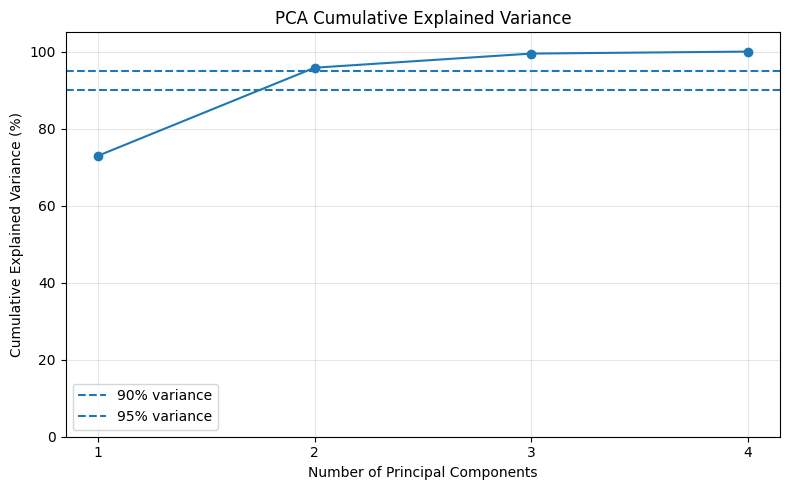

In [15]:
plt.figure(figsize=(8, 5))
plt.plot(components, cumulative * 100, marker="o")
plt.axhline(90, linestyle="--", label="90% variance")
plt.axhline(95, linestyle="--", label="95% variance")
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance (%)")
plt.title("PCA Cumulative Explained Variance")
plt.xticks(components)
plt.ylim(0, 105)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

## Reduce to two PCA dimensions

Two principal components are selected so that the high-dimensional data can be visualized on a 2D plot.

In [16]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print("Original dimensions:", X_scaled.shape[1])
print("Reduced dimensions:", X_pca.shape[1])
print(f"PC1 variance: {pca.explained_variance_ratio_[0]*100:.2f}%")
print(f"PC2 variance: {pca.explained_variance_ratio_[1]*100:.2f}%")
print(f"Total variance retained: {pca.explained_variance_ratio_.sum()*100:.2f}%")

Original dimensions: 4
Reduced dimensions: 2
PC1 variance: 72.96%
PC2 variance: 22.85%
Total variance retained: 95.81%


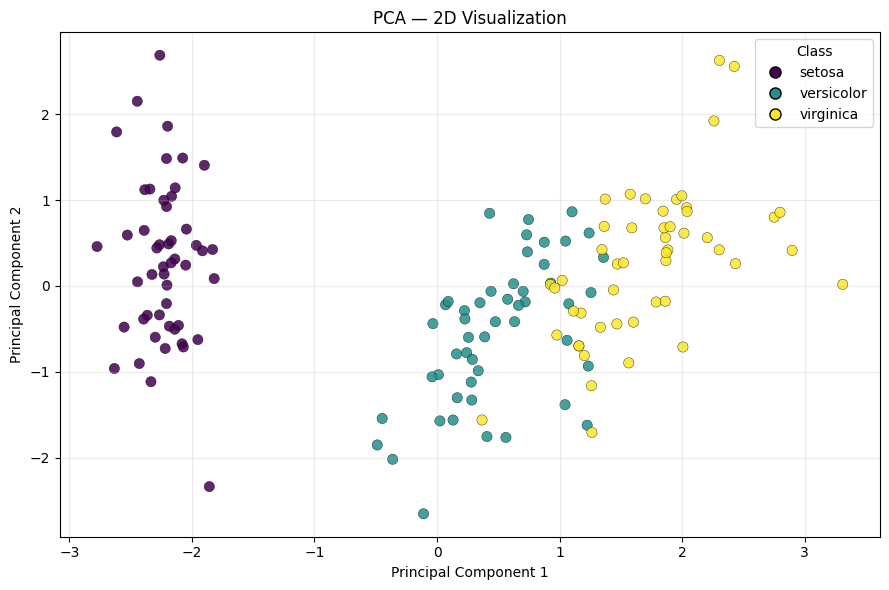

In [17]:
plt.figure(figsize=(9, 6))

if y is not None:
    labels = pd.Series(y).astype(str).astype("category")
    scatter = plt.scatter(
        X_pca[:, 0],
        X_pca[:, 1],
        c=labels.cat.codes,
        cmap="viridis",
        s=55,
        alpha=0.85,
        edgecolors="black",
        linewidths=0.3
    )

    handles = []
    for code, name in enumerate(labels.cat.categories):
        handles.append(
            plt.Line2D(
                [], [], marker="o", linestyle="",
                markerfacecolor=plt.cm.viridis(
                    code / max(1, len(labels.cat.categories)-1)
                ),
                markeredgecolor="black",
                markersize=8,
                label=name
            )
        )
    plt.legend(handles=handles, title="Class")
else:
    plt.scatter(X_pca[:, 0], X_pca[:, 1], s=55, alpha=0.85)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA — 2D Visualization")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

,PC1,PC2
sepal length (cm),0.521066,0.377418
sepal width (cm),-0.269347,0.923296
petal length (cm),0.580413,0.024492
petal width (cm),0.564857,0.066942


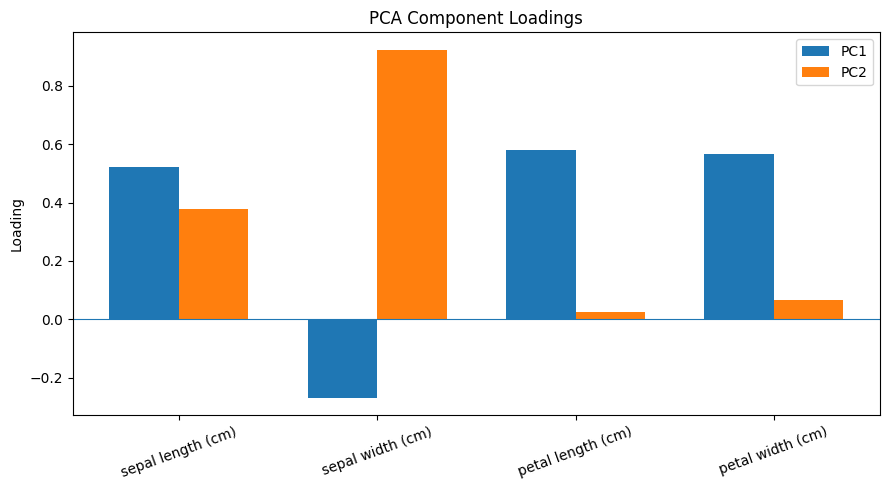

In [18]:
loadings = pd.DataFrame(
    pca.components_.T,
    index=feature_columns,
    columns=["PC1", "PC2"]
)

display(loadings)

plt.figure(figsize=(9, 5))
x_pos = np.arange(len(feature_columns))
width = 0.35

plt.bar(x_pos - width/2, loadings["PC1"], width, label="PC1")
plt.bar(x_pos + width/2, loadings["PC2"], width, label="PC2")

plt.axhline(0, linewidth=0.8)
plt.xticks(x_pos, feature_columns, rotation=20)
plt.ylabel("Loading")
plt.title("PCA Component Loadings")
plt.legend()
plt.tight_layout()
plt.show()

# t-SNE — t-Distributed Stochastic Neighbor Embedding

t-SNE is a nonlinear dimensionality-reduction technique mainly used to visualize high-dimensional data. It emphasizes local neighborhood relationships.

In [19]:
n_samples = X_scaled.shape[0]
perplexity = min(30, max(5, (n_samples - 1) // 3))

print("Number of samples:", n_samples)
print("Using perplexity:", perplexity)

tsne = TSNE(
    n_components=2,
    perplexity=perplexity,
    random_state=42,
    init="pca",
    learning_rate="auto"
)

X_tsne = tsne.fit_transform(X_scaled)

print("t-SNE completed.")
print("Output shape:", X_tsne.shape)

Number of samples: 150
Using perplexity: 30
t-SNE completed.
Output shape: (150, 2)


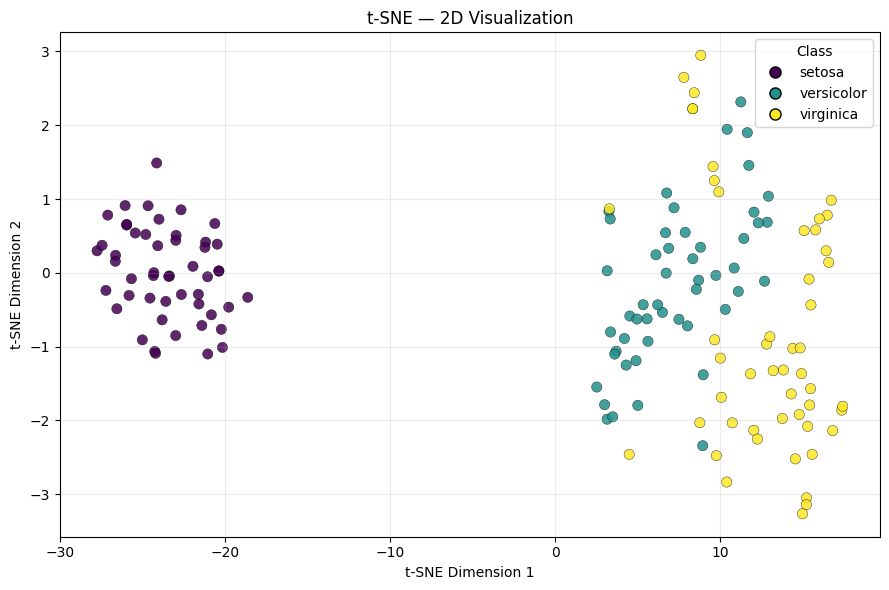

In [20]:
plt.figure(figsize=(9, 6))

if y is not None:
    labels = pd.Series(y).astype(str).astype("category")

    scatter = plt.scatter(
        X_tsne[:, 0],
        X_tsne[:, 1],
        c=labels.cat.codes,
        cmap="viridis",
        s=55,
        alpha=0.85,
        edgecolors="black",
        linewidths=0.3
    )

    handles = []
    for code, name in enumerate(labels.cat.categories):
        handles.append(
            plt.Line2D(
                [], [], marker="o", linestyle="",
                markerfacecolor=plt.cm.viridis(
                    code / max(1, len(labels.cat.categories)-1)
                ),
                markeredgecolor="black",
                markersize=8,
                label=name
            )
        )
    plt.legend(handles=handles, title="Class")
else:
    plt.scatter(X_tsne[:, 0], X_tsne[:, 1], s=55, alpha=0.85)

plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.title("t-SNE — 2D Visualization")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## PCA vs t-SNE side-by-side

PCA emphasizes directions of maximum variance, while t-SNE emphasizes local neighborhood relationships. The axes of a t-SNE plot do not have the same direct interpretation as PCA components.

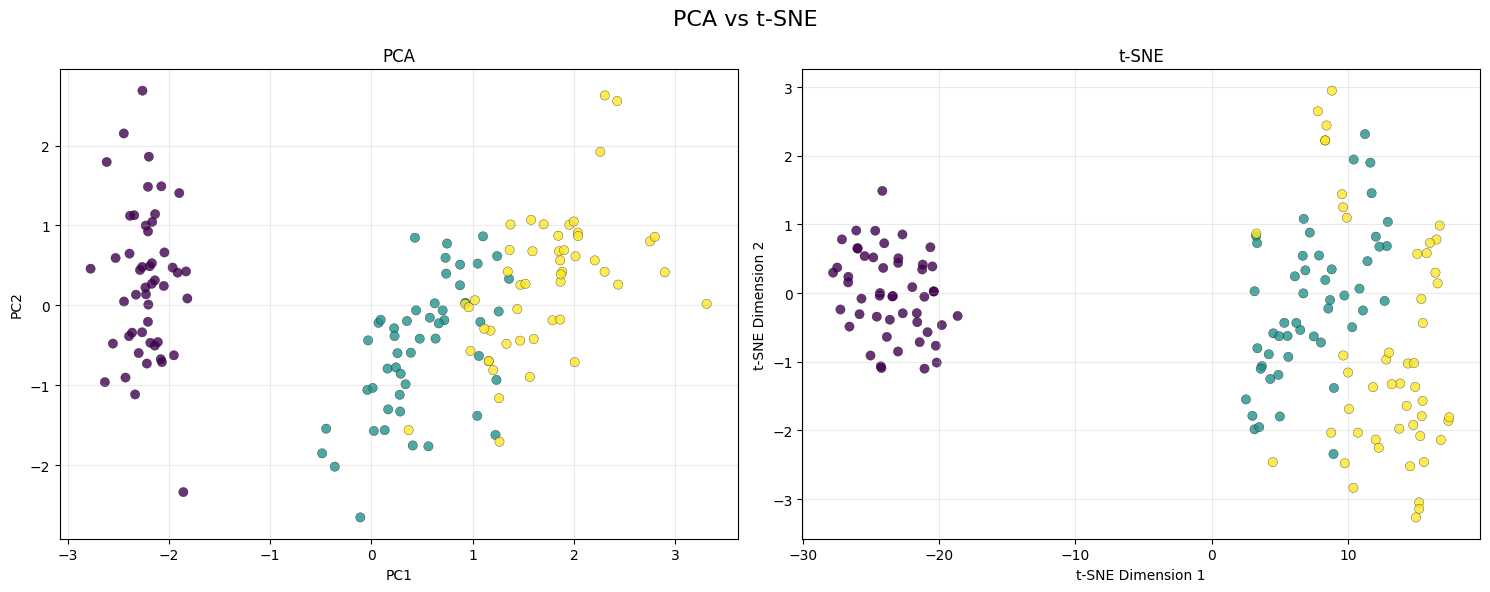

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

if y is not None:
    labels = pd.Series(y).astype(str).astype("category")
    colors = labels.cat.codes
    cmap = "viridis"
else:
    colors = None
    cmap = "viridis"

axes[0].scatter(
    X_pca[:, 0], X_pca[:, 1],
    c=colors, cmap=cmap, s=45, alpha=0.8,
    edgecolors="black", linewidths=0.25
)
axes[0].set_title("PCA")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")
axes[0].grid(alpha=0.25)

axes[1].scatter(
    X_tsne[:, 0], X_tsne[:, 1],
    c=colors, cmap=cmap, s=45, alpha=0.8,
    edgecolors="black", linewidths=0.25
)
axes[1].set_title("t-SNE")
axes[1].set_xlabel("t-SNE Dimension 1")
axes[1].set_ylabel("t-SNE Dimension 2")
axes[1].grid(alpha=0.25)

plt.suptitle("PCA vs t-SNE", fontsize=16)
plt.tight_layout()
plt.show()

In [22]:
from sklearn.metrics import pairwise_distances

print("Representation shapes:")
print("Original standardized:", X_scaled.shape)
print("PCA:", X_pca.shape)
print("t-SNE:", X_tsne.shape)

print("\nNote:")
print("- PCA is useful when a compact transformed feature representation is needed.")
print("- t-SNE is primarily an exploratory visualization method.")
print("- Global distances in a t-SNE map should not be interpreted too literally.")

Representation shapes:
Original standardized: (150, 4)
PCA: (150, 2)
t-SNE: (150, 2)

Note:
- PCA is useful when a compact transformed feature representation is needed.
- t-SNE is primarily an exploratory visualization method.
- Global distances in a t-SNE map should not be interpreted too literally.


# Conclusion

Dimensionality reduction was implemented using PCA and t-SNE.

- **PCA** reduced the original feature space into principal components and quantified how much variance was retained.
- **t-SNE** produced a 2D visualization emphasizing local neighborhood relationships.
- Original-data visualizations, PCA variance plots, PCA loadings, t-SNE visualization, and a direct PCA-vs-t-SNE comparison were generated.

**Key takeaway:** PCA is useful for linear dimensionality reduction and compact feature representations, while t-SNE is especially useful for exploring and visualizing high-dimensional structure.